In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
import seaborn as sns

2026-03-01 19:09:31.057887: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-01 19:09:31.890065: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-01 19:09:33.487738: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
CSV_PATH = "../processing/master_with_paths.csv"
DATASET_ROOT = "../data/render-lighting"
MATERIAL = "PlasticGlossy"
BATCH = "Batch 1 - Cycles AGX"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
df = pd.read_csv(CSV_PATH, low_memory=False)

count_filtered = df[
    (df["material_folder"].astype(str) == MATERIAL)
    & (df["batch_folder"].astype(str) == BATCH)
    & (df["num_active_lights"].astype(int).isin([1, 2, 3]))
].copy()

print(f"Total filtered rows: {len(count_filtered)}")
print(f"\nLight count distribution:")
print(count_filtered["num_active_lights"].value_counts().sort_index())
print(f"\nLight types in data:")
print(count_filtered["light_folder"].value_counts())

Total filtered rows: 5304

Light count distribution:
num_active_lights
1    3978
3    1326
Name: count, dtype: int64

Light types in data:
light_folder
Point Light     1326
Spot Light      1326
Area Light      1326
Tri Lighting    1326
Name: count, dtype: int64


In [4]:
count_filtered["image_path"] = count_filtered["image_relpath"].astype(str).apply(
    lambda p: os.path.join(DATASET_ROOT, p)
)
count_filtered = count_filtered[count_filtered["image_path"].map(os.path.exists)].reset_index(drop=True)

print(f"Images found: {len(count_filtered)}")

def load_and_preprocess_image(path: str) -> np.ndarray:
    with Image.open(path) as img:
        img = img.convert("RGB").resize(IMG_SIZE, Image.BILINEAR)
        return np.asarray(img, dtype=np.float32) / 255.0

print("Loading images...")
X_count = np.stack([load_and_preprocess_image(p) for p in count_filtered["image_path"]], axis=0)

# convert labels to 0-indexed classes (1->0, 2->1, 3->2)
y_count_raw = count_filtered["num_active_lights"].astype(int).values
y_count = y_count_raw - 1
num_count_classes = 3  # always expect 1, 2, 3 lights

print(f"\nX_count shape: {X_count.shape}")
print(f"y_count shape: {y_count.shape}")
print(f"Number of classes: {num_count_classes}")
print(f"Unique classes in data: {np.unique(y_count)}")
print(f"Class distribution: {np.bincount(y_count)}")

Images found: 5304
Loading images...

X_count shape: (5304, 224, 224, 3)
y_count shape: (5304,)
Number of classes: 3
Unique classes in data: [0 2]
Class distribution: [3978    0 1326]


In [5]:
X_count_train, X_count_test, y_count_train, y_count_test = train_test_split(
    X_count, y_count, test_size=0.2, random_state=42, stratify=y_count
)
X_count_train, X_count_val, y_count_train, y_count_val = train_test_split(
    X_count_train, y_count_train, test_size=0.2, random_state=42, stratify=y_count_train
)

print("Train/Val/Test split:")
print(f"  Train: {len(X_count_train)} samples")
print(f"  Val: {len(X_count_val)} samples")
print(f"  Test: {len(X_count_test)} samples")

Train/Val/Test split:
  Train: 3394 samples
  Val: 849 samples
  Test: 1061 samples


In [6]:
count_model = keras.Sequential([
    keras.Input(shape=(*IMG_SIZE, 3)),
    layers.Conv2D(32, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),
    layers.Conv2D(256, 3, activation="relu", padding="same"),
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_count_classes, activation="softmax", name="light_count")
])

count_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

count_model.summary()

E0000 00:00:1772413796.041410   22573 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1772413796.048011   22573 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ light_count (Dense)             │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 429,763 (1.64 MB)

 Trainable params: 429,763 (1.64 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
count_callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6)
]

count_history = count_model.fit(
    X_count_train, y_count_train,
    validation_data=(X_count_val, y_count_val),
    epochs=25,
    batch_size=BATCH_SIZE,
    callbacks=count_callbacks,
    verbose=1
)

Epoch 1/25


2026-03-01 19:09:56.489415: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 2043568128 exceeds 10% of free system memory.


107/107 ━━━━━━━━━━━━━━━━━━━━ 85s 780ms/step - accuracy: 0.7407 - loss: 0.5700 - val_accuracy: 0.7503 - val_loss: 0.4706 - learning_rate: 0.0010
Epoch 2/25
107/107 ━━━━━━━━━━━━━━━━━━━━ 83s 780ms/step - accuracy: 0.7543 - loss: 0.4721 - val_accuracy: 0.7538 - val_loss: 0.4123 - learning_rate: 0.0010
Epoch 3/25
107/107 ━━━━━━━━━━━━━━━━━━━━ 84s 781ms/step - accuracy: 0.8500 - loss: 0.3462 - val_accuracy: 0.8634 - val_loss: 0.3521 - learning_rate: 0.0010
Epoch 4/25
107/107 ━━━━━━━━━━━━━━━━━━━━ 83s 774ms/step - accuracy: 0.9255 - loss: 0.1969 - val_accuracy: 0.8834 - val_loss: 0.2476 - learning_rate: 0.0010
Epoch 5/25
107/107 ━━━━━━━━━━━━━━━━━━━━ 83s 775ms/step - accuracy: 0.9540 - loss: 0.1291 - val_accuracy: 0.9600 - val_loss: 0.0963 - learning_rate: 0.0010
Epoch 6/25
107/107 ━━━━━━━━━━━━━━━━━━━━ 83s 777ms/step - accuracy: 0.9641 - loss: 0.0902 - val_accuracy: 0.9776 - val_loss: 0.0412 - learning_rate: 0.0010
Epoch 7/25
107/107 ━━━━━━━━━━━━━━━━━━━━ 84s 781ms/step - accuracy: 0.9829 - loss:

Test Loss: 0.0000
Test Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

     1 Light       1.00      1.00      1.00       796
    3 Lights       1.00      1.00      1.00       265

    accuracy                           1.00      1061
   macro avg       1.00      1.00      1.00      1061
weighted avg       1.00      1.00      1.00      1061



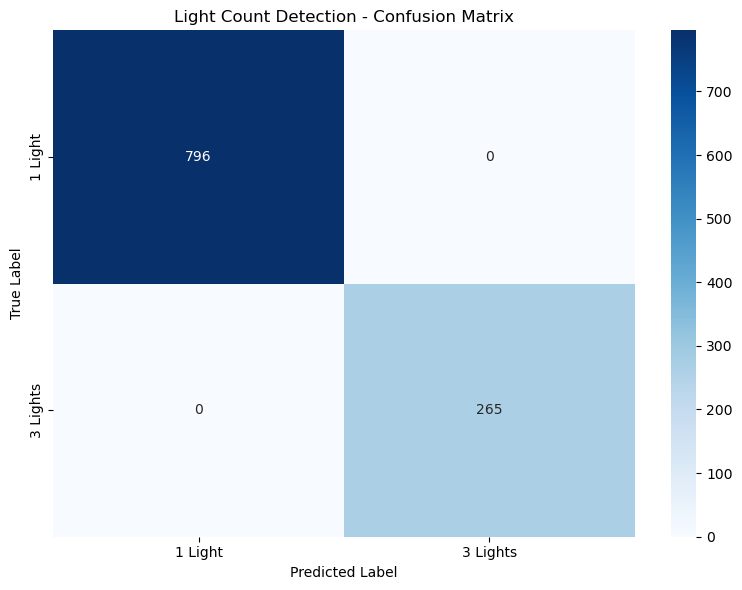

In [9]:
count_test_loss, count_test_acc = count_model.evaluate(X_count_test, y_count_test, verbose=0)
print(f"Test Loss: {count_test_loss:.4f}")
print(f"Test Accuracy: {count_test_acc:.4f}")
print()

y_count_pred = count_model.predict(X_count_test, verbose=0)
y_count_pred_classes = np.argmax(y_count_pred, axis=1)

# convert back to actual light counts (1, 2, 3) for display
class_names = ["1 Light", "3 Lights"]

print("Classification Report:")
print(classification_report(y_count_test, y_count_pred_classes, target_names=class_names))

# confusion matrix
cm = confusion_matrix(y_count_test, y_count_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Light Count Detection - Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

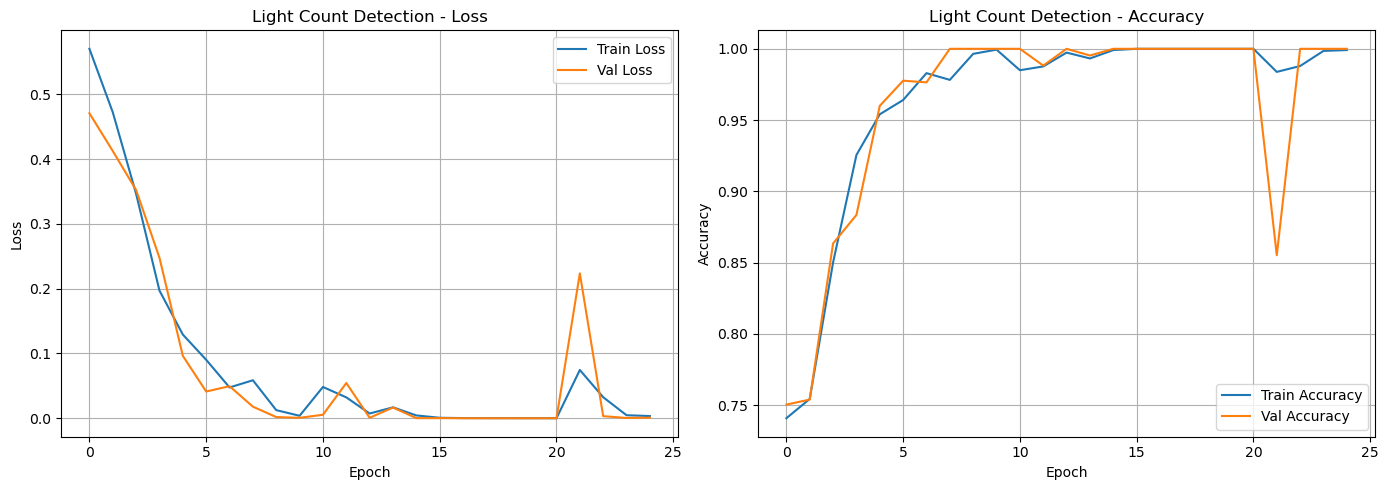

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(count_history.history["loss"], label="Train Loss")
ax1.plot(count_history.history["val_loss"], label="Val Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Light Count Detection - Loss")
ax1.legend()
ax1.grid(True)

ax2.plot(count_history.history["accuracy"], label="Train Accuracy")
ax2.plot(count_history.history["val_accuracy"], label="Val Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Light Count Detection - Accuracy")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [11]:
# save model
count_model.save("light_count_detector.keras")
print("Light count detection model saved!")

Light count detection model saved!


In [12]:
type_filtered = df[
    (df["material_folder"].astype(str) == MATERIAL)
    & (df["batch_folder"].astype(str) == BATCH)
].copy()

print(f"Total filtered rows: {len(type_filtered)}")
print(f"\nLight type distribution:")
print(type_filtered["light_folder"].value_counts())

# group HDRI types together
type_filtered["light_type"] = type_filtered["light_folder"].apply(
    lambda x: "HDRI" if "HDRI" in str(x) else str(x)
)

print(f"\nGrouped light type distribution:")
print(type_filtered["light_type"].value_counts())

Total filtered rows: 7956

Light type distribution:
light_folder
Point Light        1326
Spot Light         1326
Area Light         1326
Tri Lighting       1326
HDRI (Sunlight)    1326
HDRI (Overcast)    1326
Name: count, dtype: int64

Grouped light type distribution:
light_type
HDRI            2652
Point Light     1326
Spot Light      1326
Area Light      1326
Tri Lighting    1326
Name: count, dtype: int64


In [13]:
type_filtered["image_path"] = type_filtered["image_relpath"].astype(str).apply(
    lambda p: os.path.join(DATASET_ROOT, p)
)
type_filtered = type_filtered[type_filtered["image_path"].map(os.path.exists)].reset_index(drop=True)

print(f"Images found: {len(type_filtered)}")

print("Loading images...")
X_type = np.stack([load_and_preprocess_image(p) for p in type_filtered["image_path"]], axis=0)

# create label encoding
light_types = sorted(type_filtered["light_type"].unique())
light_type_to_idx = {lt: idx for idx, lt in enumerate(light_types)}
idx_to_light_type = {idx: lt for lt, idx in light_type_to_idx.items()}

y_type = type_filtered["light_type"].map(light_type_to_idx).values
num_type_classes = len(light_types)

print(f"\nX_type shape: {X_type.shape}")
print(f"y_type shape: {y_type.shape}")
print(f"Number of classes: {num_type_classes}")
print(f"\nClass mapping: {light_type_to_idx}")
print(f"Class distribution: {np.bincount(y_type)}")

Images found: 5304
Loading images...

X_type shape: (5304, 224, 224, 3)
y_type shape: (5304,)
Number of classes: 4

Class mapping: {'Area Light': 0, 'Point Light': 1, 'Spot Light': 2, 'Tri Lighting': 3}
Class distribution: [1326 1326 1326 1326]


In [14]:
X_type_train, X_type_test, y_type_train, y_type_test = train_test_split(
    X_type, y_type, test_size=0.2, random_state=42, stratify=y_type
)
X_type_train, X_type_val, y_type_train, y_type_val = train_test_split(
    X_type_train, y_type_train, test_size=0.2, random_state=42, stratify=y_type_train
)

print("Train/Val/Test split:")
print(f"  Train: {len(X_type_train)} samples")
print(f"  Val: {len(X_type_val)} samples")
print(f"  Test: {len(X_type_test)} samples")

Train/Val/Test split:
  Train: 3394 samples
  Val: 849 samples
  Test: 1061 samples


In [15]:
type_model = keras.Sequential([
    keras.Input(shape=(*IMG_SIZE, 3)),
    layers.Conv2D(32, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation="relu", padding="same"),
    layers.MaxPooling2D(),
    layers.Conv2D(256, 3, activation="relu", padding="same"),
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_type_classes, activation="softmax", name="light_type")
])

type_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

type_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ light_type (Dense)              │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 487,620 (1.86 MB)

 Trainable params: 487,620 (1.86 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
type_callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6)
]

type_history = type_model.fit(
    X_type_train, y_type_train,
    validation_data=(X_type_val, y_type_val),
    epochs=25,
    batch_size=BATCH_SIZE,
    callbacks=type_callbacks,
    verbose=1
)

Epoch 1/25


2026-03-01 20:34:18.679740: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 2043568128 exceeds 10% of free system memory.


107/107 ━━━━━━━━━━━━━━━━━━━━ 83s 775ms/step - accuracy: 0.4923 - loss: 0.9334 - val_accuracy: 0.5972 - val_loss: 0.8568 - learning_rate: 0.0010
Epoch 2/25
107/107 ━━━━━━━━━━━━━━━━━━━━ 82s 771ms/step - accuracy: 0.7148 - loss: 0.5350 - val_accuracy: 0.8681 - val_loss: 0.3130 - learning_rate: 0.0010
Epoch 3/25
107/107 ━━━━━━━━━━━━━━━━━━━━ 143s 777ms/step - accuracy: 0.8500 - loss: 0.3211 - val_accuracy: 0.9376 - val_loss: 0.1855 - learning_rate: 0.0010
Epoch 4/25
107/107 ━━━━━━━━━━━━━━━━━━━━ 82s 771ms/step - accuracy: 0.8948 - loss: 0.2492 - val_accuracy: 0.9576 - val_loss: 0.1207 - learning_rate: 0.0010
Epoch 5/25
107/107 ━━━━━━━━━━━━━━━━━━━━ 83s 775ms/step - accuracy: 0.9263 - loss: 0.1718 - val_accuracy: 0.7797 - val_loss: 0.5642 - learning_rate: 0.0010
Epoch 6/25
107/107 ━━━━━━━━━━━━━━━━━━━━ 83s 778ms/step - accuracy: 0.9414 - loss: 0.1443 - val_accuracy: 0.9564 - val_loss: 0.1051 - learning_rate: 0.0010
Epoch 7/25
107/107 ━━━━━━━━━━━━━━━━━━━━ 83s 779ms/step - accuracy: 0.9417 - loss

Test Loss: 0.0081
Test Accuracy: 0.9972

Classification Report:
              precision    recall  f1-score   support

  Area Light       1.00      1.00      1.00       265
 Point Light       0.99      1.00      0.99       265
  Spot Light       1.00      0.99      0.99       266
Tri Lighting       1.00      1.00      1.00       265

    accuracy                           1.00      1061
   macro avg       1.00      1.00      1.00      1061
weighted avg       1.00      1.00      1.00      1061



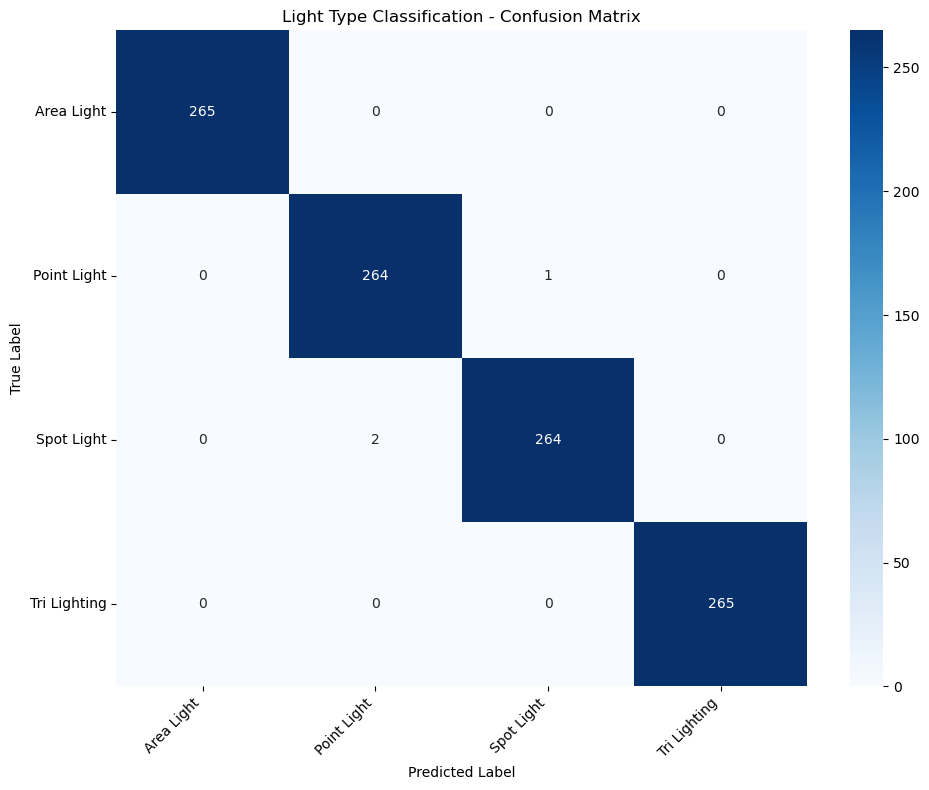

In [18]:
type_test_loss, type_test_acc = type_model.evaluate(X_type_test, y_type_test, verbose=0)
print(f"Test Loss: {type_test_loss:.4f}")
print(f"Test Accuracy: {type_test_acc:.4f}")
print()

y_type_pred = type_model.predict(X_type_test, verbose=0)
y_type_pred_classes = np.argmax(y_type_pred, axis=1)

print("Classification Report:")
print(classification_report(y_type_test, y_type_pred_classes, target_names=light_types))

# confusion matrix
cm_type = confusion_matrix(y_type_test, y_type_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_type, annot=True, fmt="d", cmap="Blues", xticklabels=light_types, yticklabels=light_types)
plt.title("Light Type Classification - Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

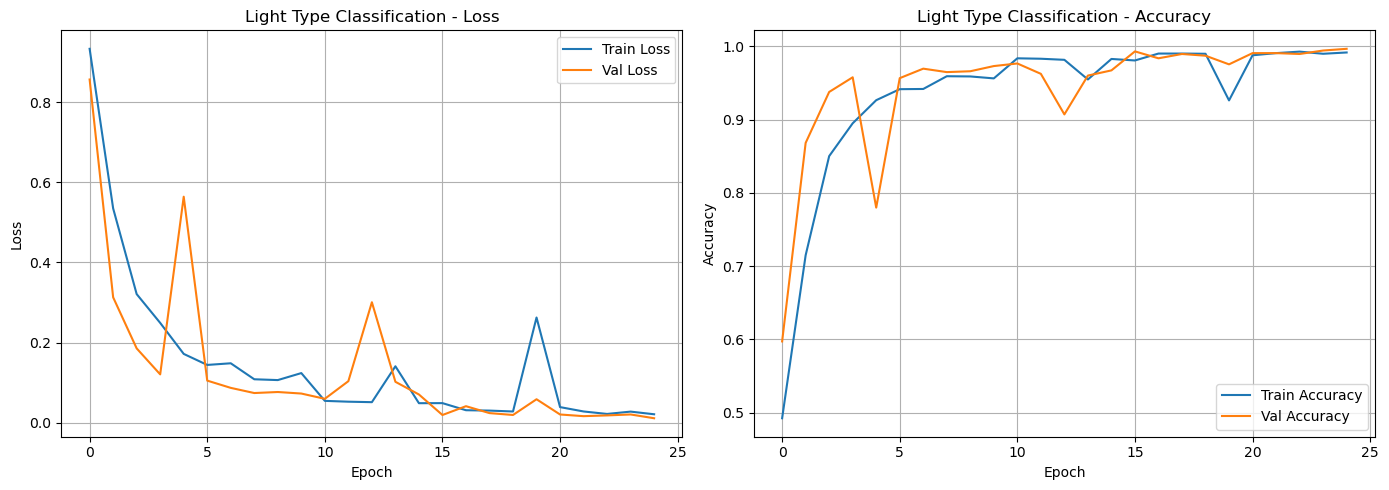

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(type_history.history["loss"], label="Train Loss")
ax1.plot(type_history.history["val_loss"], label="Val Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Light Type Classification - Loss")
ax1.legend()
ax1.grid(True)

ax2.plot(type_history.history["accuracy"], label="Train Accuracy")
ax2.plot(type_history.history["val_accuracy"], label="Val Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Light Type Classification - Accuracy")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [20]:
# save model
type_model.save("light_type_classifier.keras")
print("Light type classification model saved!")

# save label mapping
import json
with open("light_type_mapping.json", "w") as f:
    json.dump({"light_type_to_idx": light_type_to_idx, "idx_to_light_type": idx_to_light_type}, f, indent=2)
print("Label mapping saved!")

Light type classification model saved!
Label mapping saved!


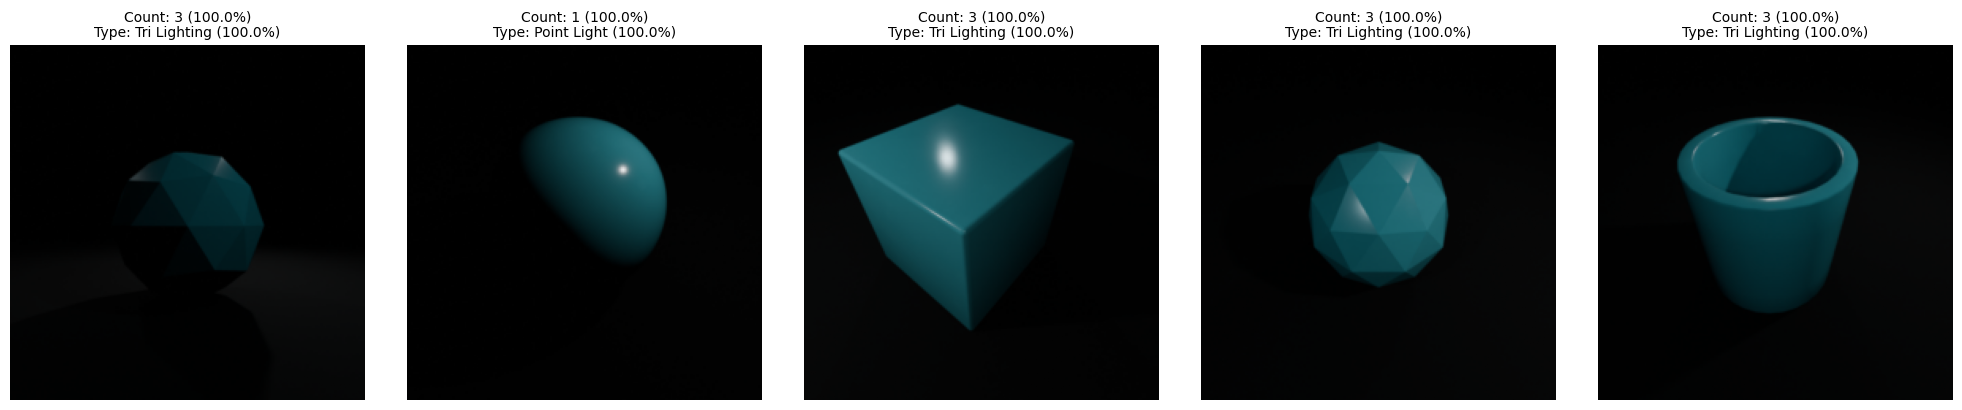

In [21]:
# test both models on random images
num_samples = 5
random_indices = np.random.choice(len(X_type_test), num_samples, replace=False)

fig, axes = plt.subplots(1, num_samples, figsize=(20, 4))
if num_samples == 1:
    axes = [axes]

for i, idx in enumerate(random_indices):
    img = X_type_test[idx]
    img_batch = np.expand_dims(img, 0)
    
    # predict count
    count_pred = count_model.predict(img_batch, verbose=0)
    count_class = np.argmax(count_pred) + 1
    count_conf = np.max(count_pred) * 100
    
    # predict type
    type_pred = type_model.predict(img_batch, verbose=0)
    type_class = np.argmax(type_pred)
    type_name = idx_to_light_type[type_class]
    type_conf = np.max(type_pred) * 100
    
    # display
    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(
        f"Count: {count_class} ({count_conf:.1f}%)\nType: {type_name} ({type_conf:.1f}%)",
        fontsize=10
    )

plt.tight_layout()
plt.show()